In [ ]:
# importação de biblioteca e do arquivo
import pandas as pd

df = pd.read_excel("../data/raw/Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Visão dos dados 

| Coluna      | O que representa  |
| ----------- | ----------------- |
| InvoiceNo   | número do pedido  |
| StockCode   | código do produto |
| Description | nome do produto   |
| Quantity    | quantidade        |
| InvoiceDate | data              |
| UnitPrice   | preço             |
| CustomerID  | cliente           |
| Country     | país              |


In [ ]:
# Informação dos tipos de dados presentes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [5]:
# verificação de valores nulos
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
# quantidade de linhas e colunas
df.shape

(541909, 8)

In [7]:
# verificar devoluções
df[df["Quantity"] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [8]:
# verificar valores estranhos de preço
df[df["UnitPrice"] <= 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom


In [9]:
# remoção das devoluções para análises de vendas
df_clean = df[df["Quantity"] > 0]

In [10]:
# remoção de preços inválidos
df_clean = df_clean[df_clean["UnitPrice"] > 0]

In [ ]:
# tratamento de CostumerID -> remoção de nulos (serão analisados comportamentos de clientes)
df_clean = df_clean.dropna(subset=["CustomerID"])

In [13]:
# resultado
df_clean.shape

(397884, 8)

#### A redução dos dados torna o processo mais confiável

In [ ]:
# criação de variável de valor
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]

In [16]:
# conferência
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [18]:
# resultado
df_clean.shape

(397884, 9)

In [27]:
# faturamento total
faturamento = df_clean["TotalPrice"].sum()

print(f"Faturamento total: £{faturamento:,.2f}")

Faturamento total: £8,911,407.90


In [28]:
# ticket médio por pedido
ticket_medio = df_clean.groupby("InvoiceNo")["TotalPrice"].sum().mean()

print(f"Ticket médio por pedido: £{ticket_medio:,.2f}")

Ticket médio por pedido: £480.87


In [21]:
# número de pedidos únicos
df_clean["InvoiceNo"].nunique()

18532

In [29]:
# número de clientes únicos
clientes = df_clean["CustomerID"].nunique()

print(f"Número de clientes únicos: {clientes:,}")

Número de clientes únicos: 4,338


In [30]:
# análise por país
top_paises = (
    df_clean.groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_paises["TotalPrice"] = top_paises["TotalPrice"].map("£{:,.2f}".format)

top_paises

,Country,TotalPrice
0,United Kingdom,"£7,308,391.55"
1,Netherlands,"£285,446.34"
2,EIRE,"£265,545.90"
3,Germany,"£228,867.14"
4,France,"£209,024.05"
5,Australia,"£138,521.31"
6,Spain,"£61,577.11"
7,Switzerland,"£56,443.95"
8,Belgium,"£41,196.34"
9,Sweden,"£38,378.33"


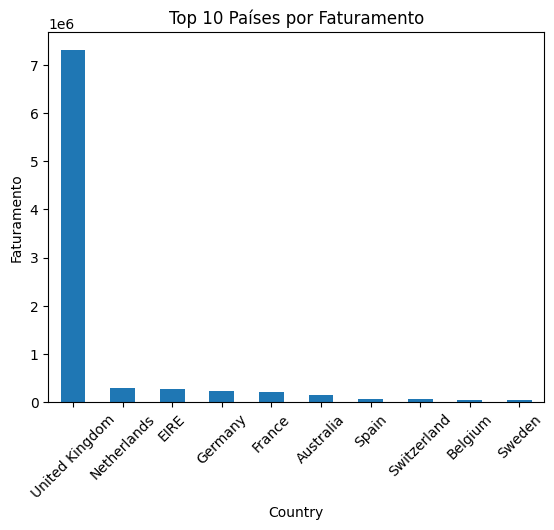

In [ ]:
# gráfico top países
import matplotlib.pyplot as plt

top_paises_plot = (
    df_clean.groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_paises_plot.plot(kind="bar")

plt.title("Top 10 Países por Faturamento")
plt.ylabel("Faturamento")
plt.xticks(rotation=45)
plt.show()

In [31]:
# produtos mais vendidos por quantidade
top_produtos = (
    df_clean.groupby("Description")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_produtos["TotalPrice"] = top_produtos["TotalPrice"].map("£{:,.2f}".format)

top_produtos

,Description,TotalPrice
0,"PAPER CRAFT , LITTLE BIRDIE","£168,469.60"
1,REGENCY CAKESTAND 3 TIER,"£142,592.95"
2,WHITE HANGING HEART T-LIGHT HOLDER,"£100,448.15"
3,JUMBO BAG RED RETROSPOT,"£85,220.78"
4,MEDIUM CERAMIC TOP STORAGE JAR,"£81,416.73"
5,POSTAGE,"£77,803.96"
6,PARTY BUNTING,"£68,844.33"
7,ASSORTED COLOUR BIRD ORNAMENT,"£56,580.34"
8,Manual,"£53,779.93"
9,RABBIT NIGHT LIGHT,"£51,346.20"


In [25]:
# produtos mais venvidos por faturamento
df_clean.groupby("Description")["TotalPrice"].sum().sort_values(ascending=False).head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: TotalPrice, dtype: float64

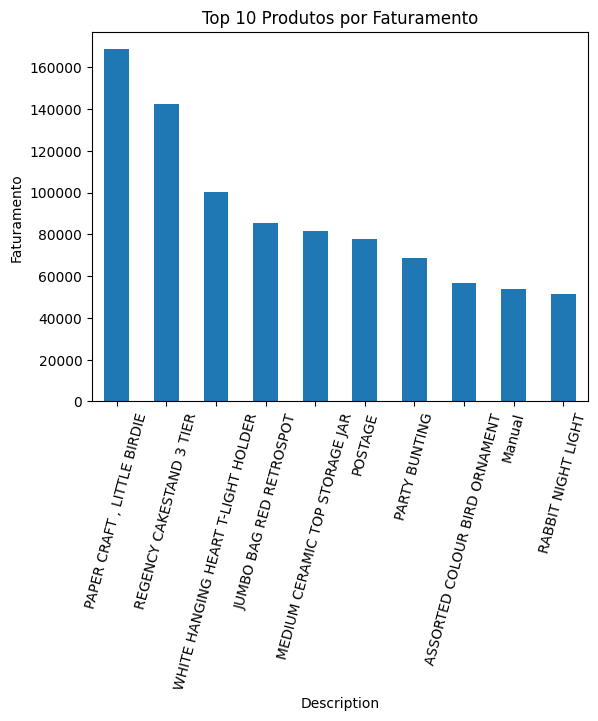

In [33]:
# gráfico top produtos por faturamento
top_produtos_plot = (
    df_clean.groupby("Description")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_produtos_plot.plot(kind="bar")

plt.title("Top 10 Produtos por Faturamento")
plt.ylabel("Faturamento")
plt.xticks(rotation=75)
plt.show()

In [26]:
# análise de clientes
df_clean.groupby("CustomerID")["TotalPrice"].sum().sort_values(ascending=False).head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: TotalPrice, dtype: float64

In [34]:
# salvar a base tratada
df_clean.to_csv("../data/processed/online_retail_clean.csv", index=False)

In [35]:
# criação de banco SQLite e importação do csv criado
import sqlite3

conn = sqlite3.connect("../data/processed/online_retail.db")
df_clean.to_sql("online_retail", conn, if_exists="replace", index=False)

print("Banco criado com sucesso!")

Banco criado com sucesso!


## Criação das consultas SQL para análises

In [36]:
# faturamento total
query = """
SELECT ROUND(SUM(TotalPrice), 2) AS faturamento_total
FROM online_retail
"""

pd.read_sql(query, conn)

,faturamento_total
0,8911407.9


In [37]:
# ticket médio por pedido
query = """
SELECT ROUND(AVG(total_pedido), 2) AS ticket_medio
FROM (
    SELECT InvoiceNo, SUM(TotalPrice) AS total_pedido
    FROM online_retail
    GROUP BY InvoiceNo
)
"""

pd.read_sql(query, conn)

,ticket_medio
0,480.87


In [38]:
# top 10 países por faturamento
query = """
SELECT Country, ROUND(SUM(TotalPrice), 2) AS faturamento
FROM online_retail
GROUP BY Country
ORDER BY faturamento DESC
LIMIT 10
"""

pd.read_sql(query, conn)

,Country,faturamento
0,United Kingdom,7308391.55
1,Netherlands,285446.34
2,EIRE,265545.90
3,Germany,228867.14
4,France,209024.05
5,Australia,138521.31
6,Spain,61577.11
7,Switzerland,56443.95
8,Belgium,41196.34
9,Sweden,38378.33


In [39]:
# top 10 produtos por faturamento
query = """
SELECT Description, ROUND(SUM(TotalPrice), 2) AS faturamento
FROM online_retail
GROUP BY Description
ORDER BY faturamento DESC
LIMIT 10
"""

pd.read_sql(query, conn)

,Description,faturamento
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1,REGENCY CAKESTAND 3 TIER,142592.95
2,WHITE HANGING HEART T-LIGHT HOLDER,100448.15
3,JUMBO BAG RED RETROSPOT,85220.78
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
5,POSTAGE,77803.96
6,PARTY BUNTING,68844.33
7,ASSORTED COLOUR BIRD ORNAMENT,56580.34
8,Manual,53779.93
9,RABBIT NIGHT LIGHT,51346.20


In [40]:
# top 10 clientes por faturamento
query = """
SELECT CustomerID, ROUND(SUM(TotalPrice), 2) AS faturamento
FROM online_retail
GROUP BY CustomerID
ORDER BY faturamento DESC
LIMIT 10
"""

pd.read_sql(query, conn)

,CustomerID,faturamento
0,14646.0,280206.02
1,18102.0,259657.30
2,17450.0,194550.79
3,16446.0,168472.50
4,14911.0,143825.06
5,12415.0,124914.53
6,14156.0,117379.63
7,17511.0,91062.38
8,16029.0,81024.84
9,12346.0,77183.60
